# Injection-January sea-ice cover

Global map of sea-ice concentration in the **injection January** (`ANTITRACER_IFRAC`, the ice
fraction that modulates the antitracer gas exchange). Each atlas polygon is classed by its
footprint-area-weighted mean January SIC:

* **ice-free** – mean SIC = 0 (no sea ice anywhere in the footprint)
* **sea-ice covered** – mean SIC > 0

Per-polygon sea-ice numbers come from `bad_curves_analysis.build_cache()` (cached to netCDF).

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pop_tools

import bad_curves_analysis as B

if not os.path.exists(B.CACHE_PATH):
    B.build_cache()
cache = B.open_cache()

In [17]:
# pop_tools grid for the mesh coordinates (the history-file TLONG/TLAT carry a
# _FillValue and come back with NaNs, which cartopy's pcolormesh rejects)
grid = pop_tools.get_grid("POP_gx1v7")
TLONG, TLAT, KMT = grid.TLONG, grid.TLAT, grid.KMT.values

sic = np.where(KMT > 0, cache.ifrac_inject_jan.values, np.nan)

plat = cache.centroid_lat.values
plon = cache.centroid_lon.values
ice_jan = cache.poly_ifrac_inject_jan.values
jan_class = np.where(ice_jan > 0, "sea-ice covered", "ice-free")

print({c: int((jan_class == c).sum()) for c in ["ice-free", "sea-ice covered"]})

{'ice-free': 587, 'sea-ice covered': 103}


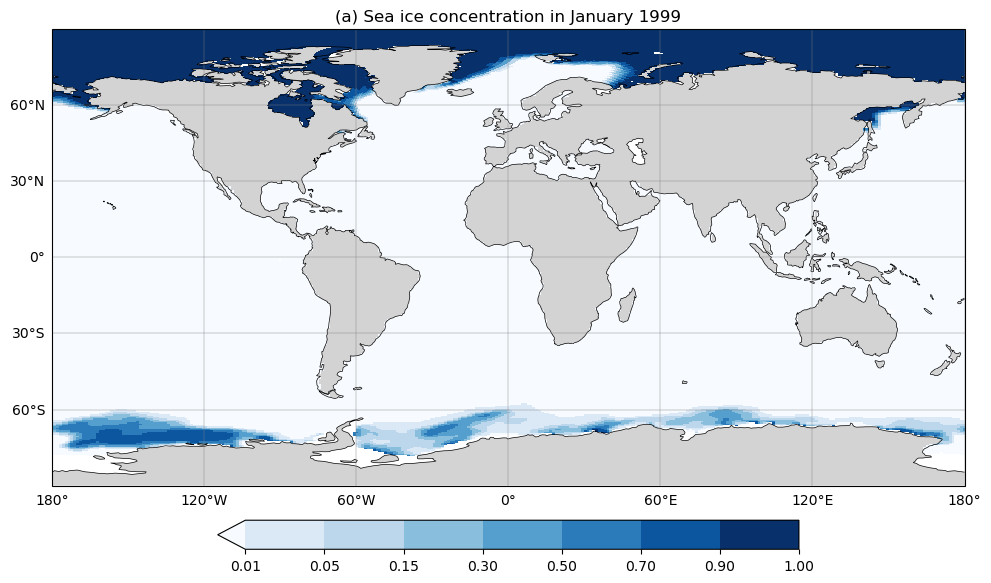

In [22]:
STYLE = {"ice-free":        ("0.45", 5,  0.5),
         "sea-ice covered": ("tab:orange", 40, 0.95)}

fig, ax = plt.subplots(figsize=(15, 7.5), subplot_kw={"projection": ccrs.PlateCarree()})

levels = np.array([0.01, 0.05, 0.15, 0.3, 0.5, 0.7, 0.9, 1.0])
cmap = plt.get_cmap("Blues")
norm = BoundaryNorm(levels, ncolors=cmap.N, extend="min")
pm = ax.pcolormesh(TLONG, TLAT, sic, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

#for cls, (color, size, alpha) in STYLE.items():
#    sel = jan_class == cls
    #ax.scatter(plon[sel], plat[sel], s=size, c=color, alpha=alpha,
    #           edgecolor="k" if cls != "ice-free" else "none", linewidth=0.3,
    #           transform=ccrs.PlateCarree(), zorder=5,
    #           label=f"{cls} (n={int(sel.sum())})")

ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.coastlines(linewidth=0.5)
ax.set_global()
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray")
gl.top_labels = gl.right_labels = False

#ax.legend(loc="lower left", bbox_to_anchor=(0.65, 0.7), fontsize=10, framealpha=0.9, markerscale=1.4)

fig.colorbar(pm, ax=ax, orientation="horizontal", shrink=0.5, pad=0.06,
             label="")
ax.set_title("(a) Sea ice concentration in January 1999")
fig.savefig("figures/seaice_january_classes.png", dpi=200, bbox_inches="tight")

## Arctic zoom

Labrador Sea / Baffin Bay zoom of the injection-January SIC with the atlas polygon
**footprint outlines** overlaid (contoured from `load_forcing_footprints`), each labelled
by polygon id.

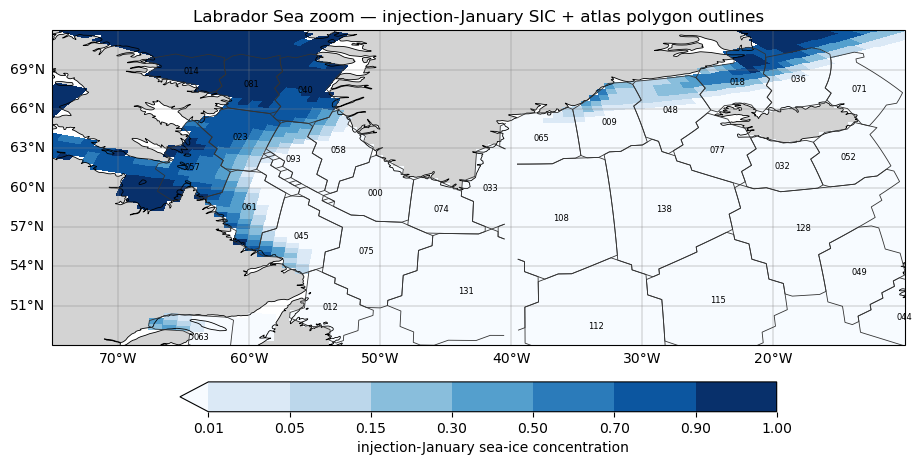

In [13]:
# curvilinear footprint masks (POP gx1v7) for the polygon outlines
masks = B.load_forcing_footprints("oae")

# Labrador Sea / Baffin Bay window (0..360 lon, to match TLONG and dodge the
# -180 dateline-wrap artifact in pcolormesh)
LON0, LON1, LAT0, LAT1 = 285, 350, 48, 72
sel = [i for i in range(B.N_POLYGONS)
       if np.isfinite(plat[i]) and LAT0 <= plat[i] <= LAT1 and LON0 <= plon[i] <= LON1]

fig, ax = plt.subplots(figsize=(11, 8),
                       subplot_kw={"projection": ccrs.PlateCarree(central_longitude=-45)})
ax.set_extent([LON0 - 360, LON1 - 360, LAT0, LAT1], ccrs.PlateCarree())

pm = ax.pcolormesh(TLONG, TLAT, sic, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.coastlines(linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray")
gl.top_labels = gl.right_labels = False


def _outline(i, **kw):
    """Contour polygon i's footprint boundary, windowed to its own grid box."""
    m = masks[i]
    if not m.any():
        return
    rr = np.where(m.any(axis=1))[0]
    cc = np.where(m.any(axis=0))[0]
    r0, r1 = max(rr[0] - 2, 0), rr[-1] + 3
    c0, c1 = max(cc[0] - 2, 0), cc[-1] + 3
    ax.contour(TLONG[r0:r1, c0:c1], TLAT[r0:r1, c0:c1],
               m[r0:r1, c0:c1].astype(float), levels=[0.5],
               transform=ccrs.PlateCarree(), zorder=6, **kw)


for i in sel:
    _outline(i, colors="0.2", linewidths=0.6)
    ax.text(plon[i], plat[i], f"{i:03d}", fontsize=6, ha="center", va="center",
            transform=ccrs.PlateCarree(), zorder=7)

fig.colorbar(pm, ax=ax, orientation="horizontal", shrink=0.7, pad=0.06,
             label="injection-January sea-ice concentration")
ax.set_title("Labrador Sea zoom — injection-January SIC + atlas polygon outlines")
fig.savefig("figures/seaice_january_arctic.png", dpi=200, bbox_inches="tight")


## Antarctic zoom

Same treatment for the Southern Ocean: a Weddell Sea / Atlantic-sector zoom
(90°W–0°, 55–80°S) of the injection-January SIC with the atlas polygon footprint
outlines overlaid, each labelled by polygon id.

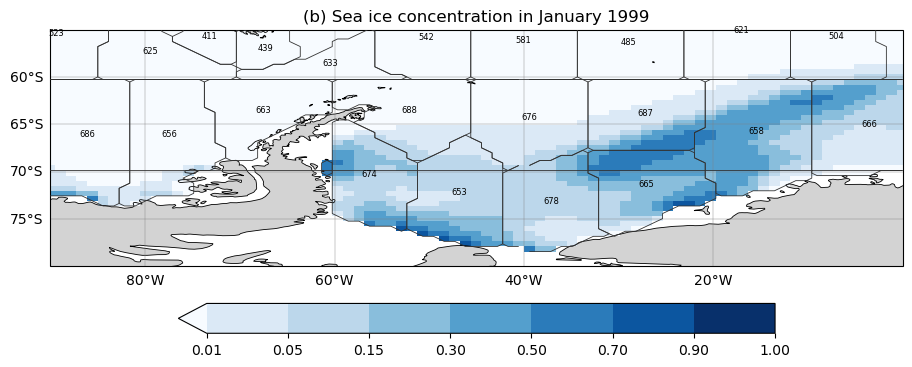

In [23]:
# Antarctic counterpart: Weddell Sea / Atlantic-sector zoom
LON0, LON1, LAT0, LAT1 = 270, 360, -80, -55   # 90W..0, 80S..55S
sel = [i for i in range(B.N_POLYGONS)
       if np.isfinite(plat[i]) and LAT0 <= plat[i] <= LAT1 and LON0 <= plon[i] <= LON1]

fig, ax = plt.subplots(figsize=(11, 8),
                       subplot_kw={"projection": ccrs.PlateCarree(central_longitude=-45)})
ax.set_extent([LON0 - 360, LON1 - 360, LAT0, LAT1], ccrs.PlateCarree())

pm = ax.pcolormesh(TLONG, TLAT, sic, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.coastlines(linewidth=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray")
gl.top_labels = gl.right_labels = False

for i in sel:
    _outline(i, colors="0.2", linewidths=0.6)
    ax.text(plon[i], plat[i], f"{i:03d}", fontsize=6, ha="center", va="center",
            transform=ccrs.PlateCarree(), zorder=7)

fig.colorbar(pm, ax=ax, orientation="horizontal", shrink=0.7, pad=0.06,
             label="")
ax.set_title("(b) Sea ice concentration in January 1999")
fig.savefig("figures/seaice_january_antarctic.png", dpi=200, bbox_inches="tight")


## Circum-Antarctic

South Polar Stereo view of the injection-January SIC south of 45°S, with all southern-hemisphere polygon footprint outlines overlaid.

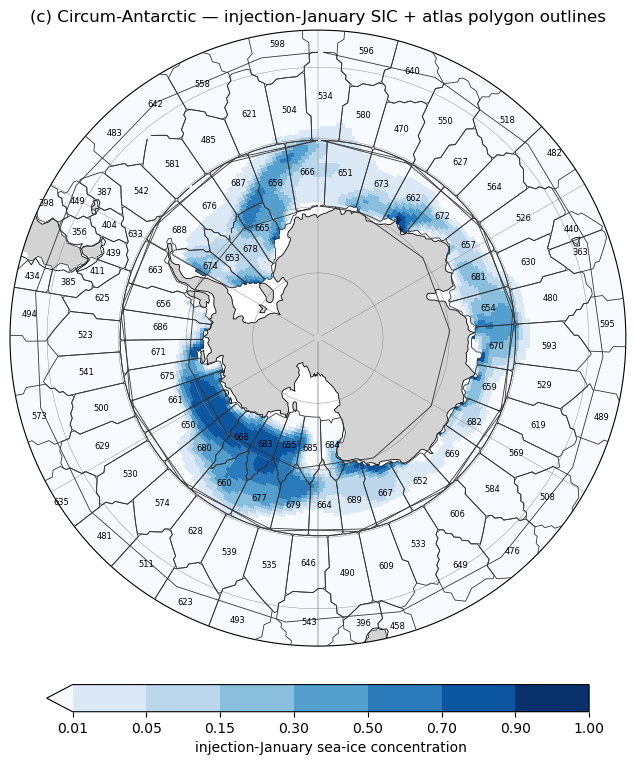

In [15]:
LAT_MAX = -45
sel = [i for i in range(B.N_POLYGONS) if np.isfinite(plat[i]) and plat[i] <= LAT_MAX]

fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, LAT_MAX], ccrs.PlateCarree())

# circular frame
theta = np.linspace(0, 2 * np.pi, 200)
verts = np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + 0.5
ax.set_boundary(mpath.Path(verts), transform=ax.transAxes)

pm = ax.pcolormesh(TLONG, TLAT, sic, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.coastlines(linewidth=0.6)
ax.gridlines(linewidth=0.3, color="gray")


def _outline_ax(ax, i, **kw):
    m = masks[i]
    if not m.any():
        return
    rr = np.where(m.any(axis=1))[0]
    cc = np.where(m.any(axis=0))[0]
    r0, r1 = max(rr[0] - 2, 0), rr[-1] + 3
    c0, c1 = max(cc[0] - 2, 0), cc[-1] + 3
    ax.contour(TLONG[r0:r1, c0:c1], TLAT[r0:r1, c0:c1],
               m[r0:r1, c0:c1].astype(float), levels=[0.5],
               transform=ccrs.PlateCarree(), zorder=6, **kw)


for i in sel:
    _outline_ax(ax, i, colors="0.2", linewidths=0.6)
    ax.text(plon[i], plat[i], f"{i:03d}", fontsize=6, ha="center", va="center",
            transform=ccrs.PlateCarree(), zorder=7)

fig.colorbar(pm, ax=ax, orientation="horizontal", shrink=0.7, pad=0.05,
             label="injection-January sea-ice concentration")
ax.set_title("(c) Circum-Antarctic — injection-January SIC + atlas polygon outlines")
fig.savefig("figures/seaice_january_circum_antarctic.png", dpi=200, bbox_inches="tight")